## Dataseti İçeri Aktarma


In [ ]:
!pip install kaggle
from google.colab import files
files.upload()  # burada kaggle.json dosyasını yükle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d jockeroika/clouds-photos
!unzip clouds-photos.zip -d clouds_photos

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/jockeroika/clouds-photos
License(s): apache-2.0
clouds-photos.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  clouds-photos.zip
replace clouds_photos/clouds_test/cirriform clouds/0208a6357f23cf53980f72dea42ade63.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace clouds_photos/clouds_test/cirriform clouds/03775c45f7cc00d8aa7eccdb482b76af.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace clouds_photos/clouds_test/cirriform clouds/04649cdcf0f8bc537233cdb724fee004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Gerekli Kütüphaneler

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Dizin Ayarlama

In [ ]:
# Google Colab'ta kullanacağın dizin
base_dir = "/content/clouds_photos"

train_dir = base_dir + "/clouds_train"
test_dir  = base_dir + "/clouds_test"

print("Train klasörü:", train_dir)
print("Test klasörü:", test_dir)


Train klasörü: /content/clouds_photos/clouds_train
Test klasörü: /content/clouds_photos/clouds_test


### Sınıfları Görüntüleme

In [ ]:
# Sınıf isimleri (bulut türleri)
classes = os.listdir(train_dir)
print("Sınıflar:", classes)

Sınıflar: ['stratocumulus clouds', 'clear sky', 'high cumuliform clouds', 'cumulonimbus clouds', 'cumulus clouds', 'cirriform clouds', 'stratiform clouds']


## Image Data Generator (Augmentasyon + Preprocessing)

In [ ]:
# Resim boyutları
img_height = 180
img_width = 180
batch_size = 32

# Eğitim verisi için augmentation
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True
)

# Test verisi augmentation İÇERMEZ — sadece normalize
test_datagen = ImageDataGenerator(rescale=1/255)

# Generator'ları oluşturma
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False  # test set shuffle edilmez
)


Found 474 images belonging to 7 classes.
Found 486 images belonging to 7 classes.


## CNN Modeli Oluşturma

In [ ]:
model = keras.Sequential([
    layers.InputLayer(input_shape=(img_height, img_width, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,879 (25.36 MB)

 Trainable params: 6,647,879 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

## Modelin Eğitilmesi

In [ ]:
epochs = 12

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.1789 - loss: 2.4942 - val_accuracy: 0.2119 - val_loss: 1.8935
Epoch 2/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.2888 - loss: 1.7796 - val_accuracy: 0.3374 - val_loss: 1.6284
Epoch 3/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3519 - loss: 1.6026 - val_accuracy: 0.3827 - val_loss: 1.4411
Epoch 4/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.3615 - loss: 1.5466 - val_accuracy: 0.3765 - val_loss: 1.4259
Epoch 5/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.4279 - loss: 1.4873 - val_accuracy: 0.5226 - val_loss: 1.2917
Epoch 6/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.4049 - loss: 1.3774 - val_accuracy: 0.3704 - val_loss: 1.4061
Epoch 7/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.4028 - loss: 1.3716 - val_accuracy: 0.4403 - val_loss: 1.2790
Epoch 8/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.4560 - loss: 1.2825 - val_accuracy: 0.3930 - val_loss:

## Accuracy / Loss Grafiklerinin Çizilmesi

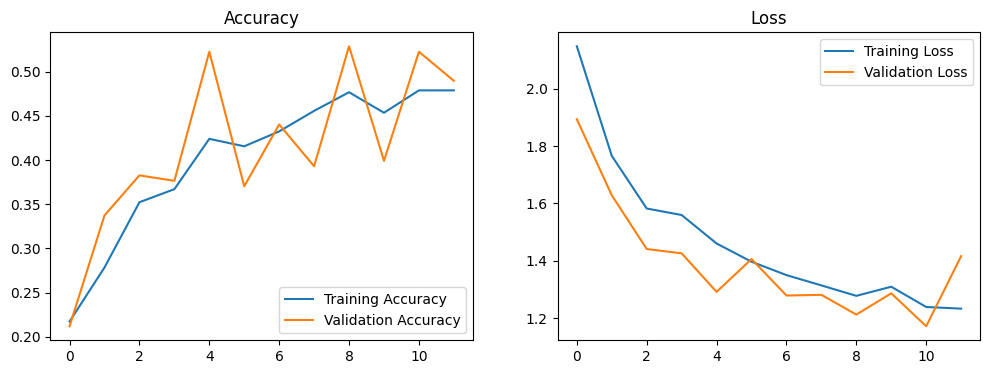

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12,4))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss Plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()


## Modelin Test Seti Üzerindeki Performansı

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("📌 Test Accuracy:", test_acc)
print("📌 Test Loss:", test_loss)


16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 523ms/step - accuracy: 0.3931 - loss: 1.6759
📌 Test Accuracy: 0.4897119402885437
📌 Test Loss: 1.4163028001785278


## Tahmin Örneği (Random Test Görüntüsü)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


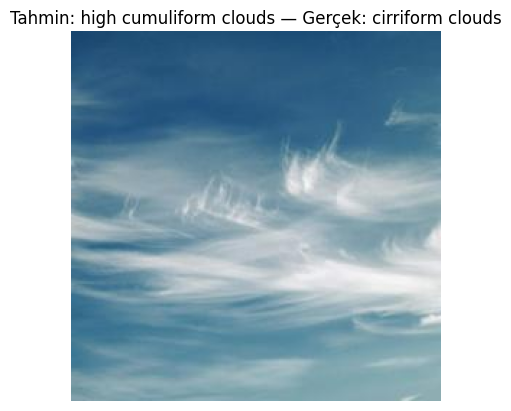

In [ ]:
import random
from tensorflow.keras.preprocessing import image

# Test klasöründen rastgele bir resim seç
random_class = random.choice(classes)
random_image = random.choice(os.listdir(test_dir + "/" + random_class))
img_path = test_dir + "/" + random_class + "/" + random_image

# Resmi yükle
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Tahmin yap
prediction = model.predict(img_array)
predicted_class = classes[np.argmax(prediction)]

# Görüntüle
plt.imshow(image.load_img(img_path))
plt.title(f"Tahmin: {predicted_class} — Gerçek: {random_class}")
plt.axis("off")
plt.show()
